In [1]:
import numpy as np
import tensorflow as tf

In [2]:
(x_train,y_train),(x_test,y_test) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [4]:
x_train_flatten = x_train.reshape(-1,28*28)
x_test_flatten = x_test.reshape(-1,28*28)
print(x_train_flatten.shape)
print(x_test_flatten.shape)



(60000, 784)
(10000, 784)


In [5]:


x_train_normalized = (x_train_flatten)/255
x_test_normalized = (x_test_flatten)/255
print(x_train_normalized.shape)
print(x_test_normalized.shape)

(60000, 784)
(10000, 784)


In [6]:
y_train_encoded = np.eye(10)[y_train]
y_test_encoded = np.eye(10)[y_test]

print(y_train_encoded)
print(y_test_encoded)


[[0. 0. 0. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [7]:
def relu(z):
  return np.maximum(0,z)

In [8]:
def softmax(z):
  max = np.max(z,axis=1,keepdims=True)
  z = z-max
  ez = np.exp(z)
  sm = ez/np.sum(ez,axis=1,keepdims=True)
  return sm


In [9]:
w1 = np.random.randn(784,128)*np.sqrt(2.0/784)
b1 = np.zeros((1,128))
w2 = np.random.randn(128,10)*np.sqrt(2.0/128)
b2 = np.zeros((1,10))

In [10]:
def forward_pass (x,w1,b1,w2,b2):
  z1 = np.dot(x,w1)+b1
  a1 = relu(z1)
  z2 = np.dot(a1,w2)+b2
  a2= softmax(z2)
  return z1,a1,z2,a2

In [11]:
def relu_derivative(z):
  return 1.0 * (z>0)

In [12]:
def backward_pass(x,y,z1,a1,a2,w2):
  m = x.shape[0]
  dz2= a2-y
  dw2 = np.dot(a1.T,dz2)/m
  db2 = np.sum(dz2,axis=0,keepdims=True)/m

  dz1 = np.dot(dz2,w2.T)*relu_derivative(z1)
  dw1 = np.dot(x.T,dz1)/m
  db1 = np.sum(dz1,axis=0,keepdims=True)/m

  return dw1,db1,dw2,db2

In [13]:
def compute_loss(a2,y):
  m = y.shape[0]
  a2 = np.clip(a2,1e-15,1-1e-15)
  loss = -np.sum(y*np.log(a2))/m
  return loss

In [19]:
learning_rate = 0.2
epochs = 100
loss_history = []



In [20]:
for epoch in range (epochs):
  z1,a1,z2,a2 = forward_pass(x_train_normalized,w1,b1,w2,b2)
  loss = compute_loss(a2,y_train_encoded)
  loss_history.append(loss)
  dw1,db1,dw2,db2 = backward_pass(x_train_normalized,y_train_encoded,z1,a1,a2,w2)
  w1 = w1-learning_rate*dw1
  b1 = b1-learning_rate*db1
  w2 = w2-learning_rate*dw2
  b2 = b2-learning_rate*db2

  if epoch%10==0:
    print(f"Epoch {epoch}, Loss: {loss}")


Epoch 0, Loss: 0.9437043725920107
Epoch 10, Loss: 0.7971790242311639
Epoch 20, Loss: 0.8088866440256097
Epoch 30, Loss: 0.7104787633854222
Epoch 40, Loss: 0.6782657759346192
Epoch 50, Loss: 0.6469657525463595
Epoch 60, Loss: 0.6353786334100531
Epoch 70, Loss: 0.6235349474377693
Epoch 80, Loss: 0.6027614482465155
Epoch 90, Loss: 0.6059741976927873


In [21]:
z1,a1,z2,a2 = forward_pass(x_test_normalized,w1,b1,w2,b2)
test_loss = compute_loss(a2,y_test_encoded)
print(f"Test Loss: {test_loss}")

predicted_classes = np.argmax(a2, axis=1)
true_classes = np.argmax(y_test_encoded, axis=1)
accuracy = np.mean(predicted_classes == true_classes) * 100
print(f"Test Accuracy: {accuracy:.2f}%")


Test Loss: 0.6108577156462913
Test Accuracy: 78.44%


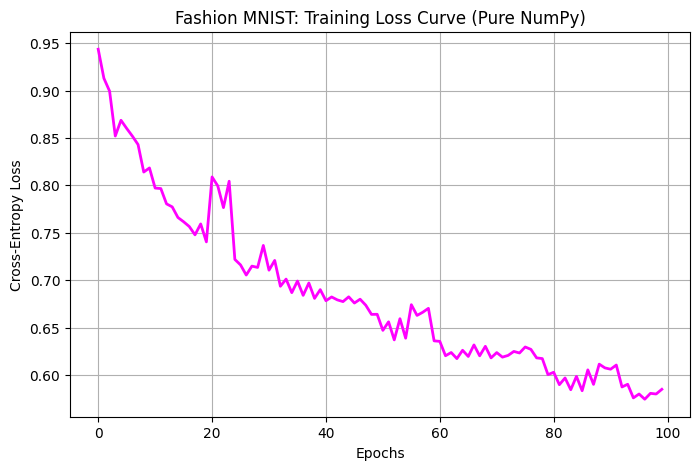

In [22]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='magenta', linewidth=2)

# Add descriptions
plt.title('Fashion MNIST: Training Loss Curve (Pure NumPy)')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True)

# Render the graph
plt.show()


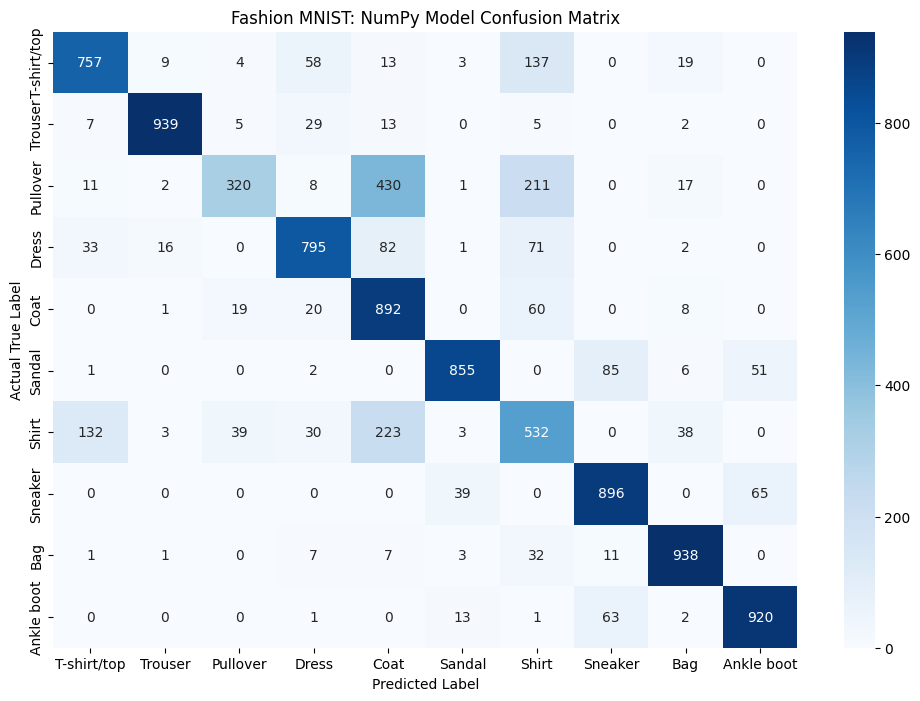


--- Class-wise Accuracy ---
T-shirt/top : 75.70%
Trouser     : 93.90%
Pullover    : 32.00%
Dress       : 79.50%
Coat        : 89.20%
Sandal      : 85.50%
Shirt       : 53.20%
Sneaker     : 89.60%
Bag         : 93.80%
Ankle boot  : 92.00%


In [24]:
# Run test data through the network to get final outputs
_, _, _, a2_test = forward_pass(x_test_normalized, w1, b1, w2, b2)

# Convert the probabilities and one-hot encodings back to standard 0-9 labels
predicted_classes = np.argmax(a2_test, axis=1)
true_classes = np.argmax(y_test_encoded, axis=1)

# 1. Generate the Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Fashion MNIST exact class names
fashion_classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 1. Generate the Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=fashion_classes,
            yticklabels=fashion_classes)
plt.title('Fashion MNIST: NumPy Model Confusion Matrix')
plt.ylabel('Actual True Label')
plt.xlabel('Predicted Label')
plt.show()

# 2. Calculate Class-wise Accuracy
# The diagonal of the matrix contains correct predictions. We divide by the total per row.
class_accuracies = cm.diagonal() / cm.sum(axis=1)

print("\n--- Class-wise Accuracy ---")
for i, acc in enumerate(class_accuracies):
    print(f"{fashion_classes[i]:<12}: {acc * 100:.2f}%")